Found 5712 files belonging to 4 classes.
Using 5141 files for training.
Found 5712 files belonging to 4 classes.
Using 571 files for validation.
Found 1311 files belonging to 4 classes.
Class Names: ['glioma', 'meningioma', 'notumor', 'pituitary']


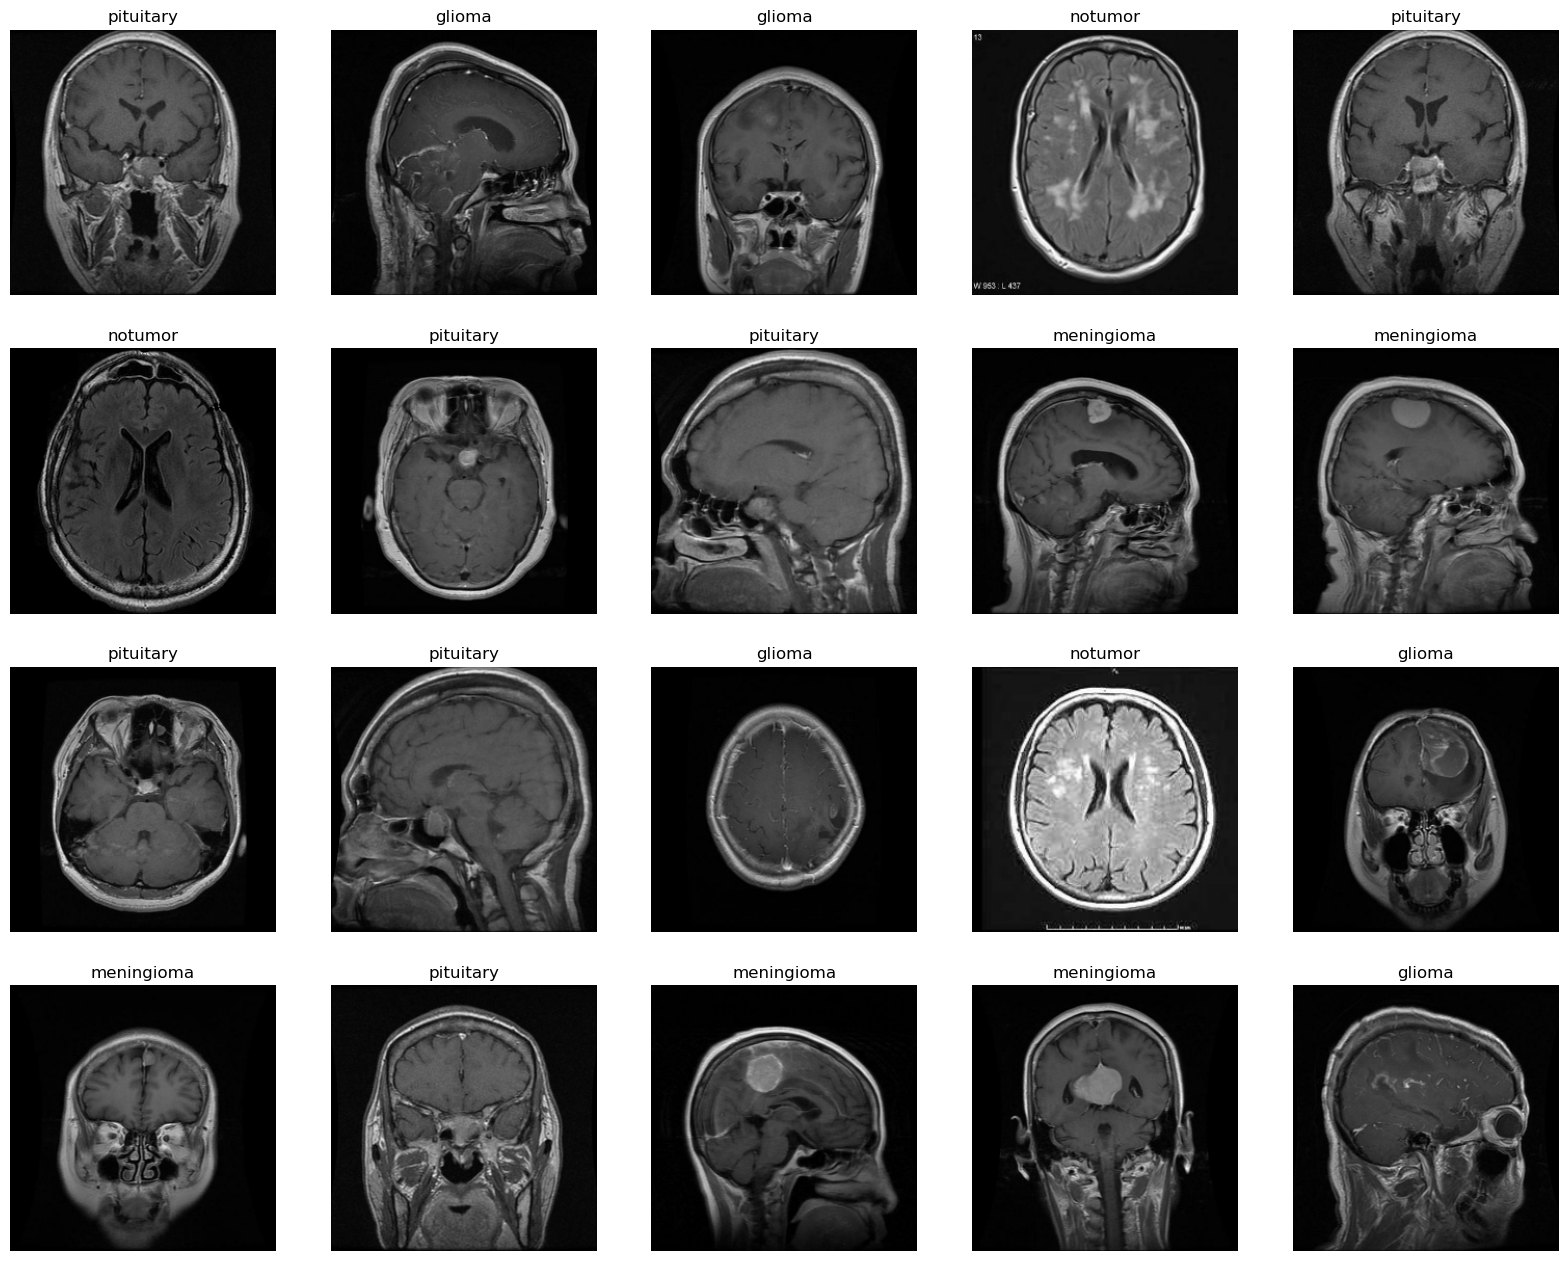

Number of Classes: 4


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Rescaling, Input, Dense, Conv2D, MaxPool2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

dataset_path = 'archive (3)'
batch_size = 64
image_size = (256, 256)

train_data_path = dataset_path + "/Training/"
train_ds = image_dataset_from_directory(
    train_data_path,
    validation_split=0.1,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)
val_ds = image_dataset_from_directory(
    train_data_path,
    validation_split=0.1,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)
test_data_path = dataset_path + "/Testing/"
test_ds = image_dataset_from_directory(
    test_data_path,
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)
class_names = train_ds.class_names
print("Class Names:", class_names)

# عرض بعض الصور من مجموعة التدريب
plt.figure(figsize=(20, 20))
for images, labels in train_ds.take(1):
    for i in range(20):
        ax = plt.subplot(5, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

normalizing_images = tf.keras.layers.Rescaling(1/255.)
normalized_dataset_train = train_ds.map(lambda x, y: (normalizing_images(x), y))
normalized_dataset_val = val_ds.map(lambda x, y: (normalizing_images(x), y))
normalized_dataset_test = test_ds.map(lambda x, y: (normalizing_images(x), y))

AUTOTUNE = tf.data.AUTOTUNE
normalized_dataset_train = normalized_dataset_train.prefetch(buffer_size=AUTOTUNE)
normalized_dataset_val = normalized_dataset_val.prefetch(buffer_size=AUTOTUNE)
normalized_dataset_test = normalized_dataset_test.prefetch(buffer_size=AUTOTUNE)

# تحديد عدد الفئات
num_classes = len(class_names)
print("Number of Classes:", num_classes)


Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.4654 - loss: 1.2025 - val_accuracy: 0.7671 - val_loss: 0.6873
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.6985 - loss: 0.7547 - val_accuracy: 0.8039 - val_loss: 0.5494
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.7594 - loss: 0.6449 - val_accuracy: 0.8214 - val_loss: 0.4901
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.7743 - loss: 0.5856 - val_accuracy: 0.8336 - val_loss: 0.4526
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.7935 - loss: 0.5560 - val_accuracy: 0.8371 - val_loss: 0.4414
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 227s 3s/step - accuracy: 0.8019 - loss: 0.5187 - val_accuracy: 0.8284 - val_loss: 0.4292
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.8150 - loss: 0.4931 - val_accuracy: 0.8266 - val_loss: 0.4300
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.8211 - loss: 0.4873 - val_accuracy: 0.8284 - v

C:\Program Files\condaaaa\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 914 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8341 - loss: 0.4023
Test Accuracy: 83.68%


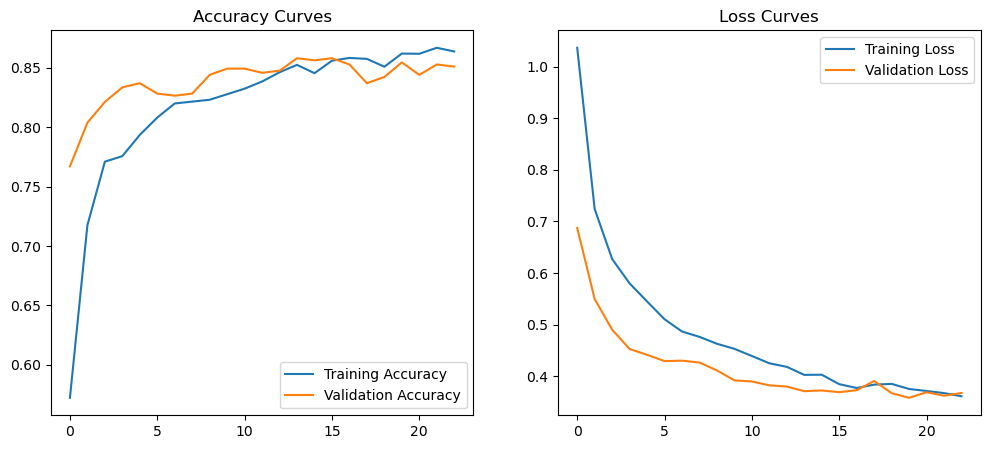

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# Data preprocessing and augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
])
base_model = EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
    input_shape=(256, 256, 3)
)
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(train_ds.class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


model.load_weights('jj.keras')
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()

In [ ]:
model.save("MOH.keras")

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("\n" + "="*50)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print("="*50 + "\n")

21/21 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8256 - loss: 0.4321

Final Test Accuracy: 83.68%



In [ ]:
# Configure GPU for maximum performance
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable mixed precision and memory growth
        tf.config.optimizer.set_jit(True)
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Using GPU: {gpus[0]}")
    except RuntimeError as e:
        print(e)
else:
    print("Using CPU")

Using CPU


In [ ]:
# Unfreeze base model
base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),  # Lower LR
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

# 2. Train with reduced patience
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[EarlyStopping(patience=2)]
)


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 12476s 145s/step - accuracy: 0.7045 - loss: 0.7831 - val_accuracy: 0.8091 - val_loss: 0.4723
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 17307s 205s/step - accuracy: 0.8299 - loss: 0.4776 - val_accuracy: 0.8424 - val_loss: 0.3853
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 15271s 183s/step - accuracy: 0.8651 - loss: 0.3806 - val_accuracy: 0.8774 - val_loss: 0.3266
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 10705s 116s/step - accuracy: 0.8938 - loss: 0.2966 - val_accuracy: 0.8897 - val_loss: 0.2946
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 36528s 448s/step - accuracy: 0.9061 - loss: 0.2705 - val_accuracy: 0.9072 - val_loss: 0.2553
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 33879s 408s/step - accuracy: 0.9223 - loss: 0.2247 - val_accuracy: 0.9124 - val_loss: 0.2344
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 33823s 406s/step - accuracy: 0.9274 - loss: 0.2056 - val_accuracy: 0.9212 - val_loss: 0.2094
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 30084s 366s/step - accuracy: 0.9320 - loss: 0

In [ ]:
model.save("MOH_full.keras")

# Save just weights
model.save_weights("MOH_weights.weights.h5")

# Later loading
loaded_model = tf.keras.models.load_model("MOH_full.keras")  # Full model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("\n" + "="*50)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print("="*50 + "\n")

21/21 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.9190 - loss: 0.2168

Final Test Accuracy: 92.83%



In [ ]:

# 4. Optional: Class-wise metrics
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 192s 192s/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.92      0.93       300
  meningioma       0.93      0.81      0.86       306
     notumor       0.97      0.97      0.97       4

In [ ]:

# 2. Load the model (REQUIRED)
loaded_model = tf.keras.models.load_model("MOH_full.keras")

# 3. Verify predictions
sample_image = next(iter(test_ds))[0][0]
prediction = loaded_model.predict(tf.expand_dims(sample_image, 0))
print("Predicted class:", class_names[tf.argmax(prediction[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 112s 112s/step
Predicted class: notumor
